In [1]:
!pip install -q monai

import os
import tarfile
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd,
    NormalizeIntensityd, ConcatItemsd, RandFlipd, RandRotate90d,
    MapLabelValued, ToTensord, AsDiscrete, SpatialPadd, RandSpatialCropd,
)
from monai.data import Dataset, DataLoader, decollate_batch
from monai.networks.nets import AttentionUnet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 44.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.1 MB/s eta 0:00:00:00:0100:01


<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-12 06:01:38.194931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775973698.368872      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775973698.417611      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# ── Device ──────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ── Data extraction ──────────────────────────────────────────────────────────
input_tar  = "/kaggle/input/brats-2021-task1/BraTS2021_Training_Data.tar"
output_dir = "/kaggle/working/BraTS2021/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print("Extracting dataset...")
    with tarfile.open(input_tar) as tar:
        tar.extractall(path=output_dir)
    print("Done.")

Extracting dataset...
Done.


In [4]:
# ── Build file list ──────────────────────────────────────────────────────────
data_dicts = []
for p_id in sorted(next(os.walk(output_dir))[1]):
    p_path = os.path.join(output_dir, p_id)
    flair = os.path.join(p_path, f"{p_id}_flair.nii.gz")
    if os.path.exists(flair):
        data_dicts.append({
            "flair": flair,
            "t1":    os.path.join(p_path, f"{p_id}_t1.nii.gz"),
            "t1ce":  os.path.join(p_path, f"{p_id}_t1ce.nii.gz"),
            "t2":    os.path.join(p_path, f"{p_id}_t2.nii.gz"),
            "label": os.path.join(p_path, f"{p_id}_seg.nii.gz"),
        })

n = len(data_dicts)
train_files = data_dicts[:int(n * 0.8)]
val_files   = data_dicts[int(n * 0.8):int(n * 0.9)]
test_files  = data_dicts[int(n * 0.9):]
print(f"Total: {n}  Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Total: 1251  Train: 1000  Val: 125  Test: 126


In [5]:
# ── Shared keys used by every transform ─────────────────────────────────────
IMG_KEYS   = ["flair", "t1", "t1ce", "t2"]
ALL_KEYS   = IMG_KEYS + ["label"]

def base_transforms():
    """Steps that are identical for train, val, and test."""
    return [
        LoadImaged(keys=ALL_KEYS),
        EnsureChannelFirstd(keys=ALL_KEYS),
        Orientationd(keys=ALL_KEYS, axcodes="RAS"),
        # BraTS label 4 → 3  (necrotic=1, edema=2, enhancing=3)
        MapLabelValued(keys="label", orig_labels=[0,1,2,4], target_labels=[0,1,2,3]),
        ConcatItemsd(keys=IMG_KEYS, name="image"),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        # Pad so every volume is at least 128³ before cropping / inference
        SpatialPadd(keys=["image", "label"], spatial_size=(128, 128, 64)),
        ToTensord(keys=["image", "label"]),
    ]

train_transforms = Compose(base_transforms() + [
    RandSpatialCropd(keys=["image", "label"], roi_size=(128, 128, 64), random_size=False),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[0, 1, 2]),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
])

val_test_transforms = Compose(base_transforms())

train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds   = Dataset(data=val_files,   transform=val_test_transforms)
test_ds  = Dataset(data=test_files,  transform=val_test_transforms)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [6]:
# ── Model, loss, optimiser ───────────────────────────────────────────────────
# ResUNet
from monai.networks.nets import UNet
model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

loss_fn    = DiceCELoss(to_onehot_y=True, softmax=True, include_background=True)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-4)
dice_metric = DiceMetric(include_background=True, reduction="mean")
scaler     = torch.amp.GradScaler("cuda")

post_pred  = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

ROI = (128, 128, 64)

In [7]:
# Base UNet
# from monai.networks.nets import UNet
# model = UNet(
#     spatial_dims=3,
#     in_channels=4,
#     out_channels=4,
#     channels=(16, 32, 64, 128, 256),
#     strides=(2, 2, 2, 2),
# ).to(device)

# ResUNet
# from monai.networks.nets import UNet
# model = UNet(
#     spatial_dims=3,
#     in_channels=4,
#     out_channels=4,
#     channels=(16, 32, 64, 128, 256),
#     strides=(2, 2, 2, 2),
#     num_res_units=2,
# ).to(device)

# UNet++ (DynUNet)
# from monai.networks.nets import DynUNet
# model = DynUNet(
#     spatial_dims=3,
#     in_channels=4,
#     out_channels=4,
#     kernel_size=[3, 3, 3, 3, 3],
#     strides=[1, 2, 2, 2, 2],
#     upsample_kernel_size=[2, 2, 2, 2],
#     filters=[16, 32, 64, 128, 256],
#     norm_name="instance",
#     deep_supervision=False,
# ).to(device)

In [8]:
# ── Training loop ────────────────────────────────────────────────────────────
EPOCHS = 15
train_losses, val_losses, val_dices = [], [], []

for epoch in range(EPOCHS):
    # ---- train ----
    model.train()
    running_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs   = batch["image"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            loss = loss_fn(model(imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    avg_train = running_loss / len(train_loader)
    train_losses.append(avg_train)

    # ---- validate ----
    model.eval()
    running_val_loss = 0.0
    dice_metric.reset()

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            imgs   = batch["image"].to(device)
            labels = batch["label"].to(device)
            with torch.amp.autocast("cuda"):
                outputs = sliding_window_inference(imgs, ROI, sw_batch_size=2, predictor=model, overlap=0.5)
                running_val_loss += loss_fn(outputs, labels).item()
            preds = [post_pred(o) for o in decollate_batch(outputs)]
            lbls  = [post_label(l) for l in decollate_batch(labels)]
            dice_metric(y_pred=preds, y=lbls)

    avg_val  = running_val_loss / len(val_loader)
    avg_dice = dice_metric.aggregate().item()
    dice_metric.reset()

    val_losses.append(avg_val)
    val_dices.append(avg_dice)
    print(f"Epoch {epoch+1}  Train Loss: {avg_train:.4f}  Val Loss: {avg_val:.4f}  Val Dice: {avg_dice:.4f}")

Epoch 1/15 [Val]: 100%|██████████| 125/125 [02:27<00:00,  1.18s/it]


Epoch 1  Train Loss: 1.5040  Val Loss: 0.9024  Val Dice: 0.4600


Epoch 2/15 [Val]: 100%|██████████| 125/125 [02:24<00:00,  1.15s/it]


Epoch 2  Train Loss: 0.7621  Val Loss: 0.6864  Val Dice: 0.5493


Epoch 3/15 [Val]: 100%|██████████| 125/125 [02:22<00:00,  1.14s/it]


...

Epoch 13  Train Loss: 0.3765  Val Loss: 0.3834  Val Dice: 0.6965


Epoch 14/15 [Val]: 100%|██████████| 125/125 [02:19<00:00,  1.11s/it]


Epoch 14  Train Loss: 0.3770  Val Loss: 0.4068  Val Dice: 0.6731


Epoch 15/15 [Val]: 100%|██████████| 125/125 [02:21<00:00,  1.13s/it]

Epoch 15  Train Loss: 0.3666  Val Loss: 0.4249  Val Dice: 0.6556


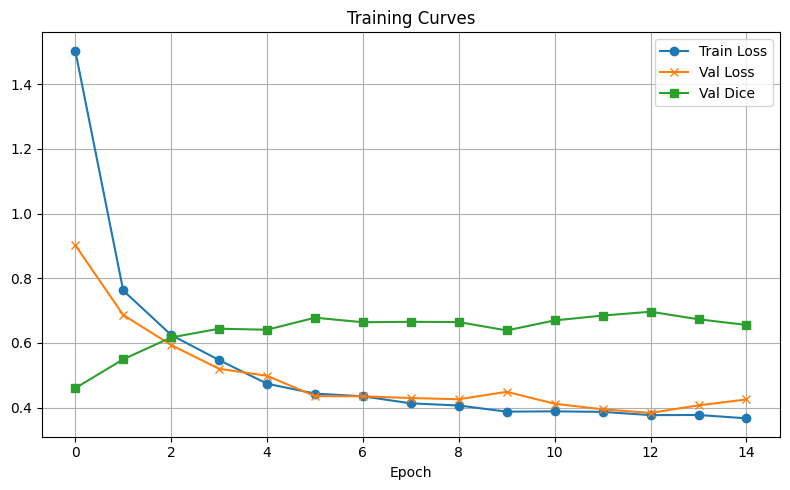

In [9]:
# ── Loss curves ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss",      marker="o")
plt.plot(val_losses,   label="Val Loss",        marker="x")
plt.plot(val_dices,    label="Val Dice",        marker="s")
plt.title("Training Curves")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# ── Test evaluation ──────────────────────────────────────────────────────────
print("\n--- Test Evaluation ---")
model.eval()
dice_metric.reset()
test_loss_sum = 0.0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        imgs   = batch["image"].to(device)
        labels = batch["label"].to(device)
        with torch.amp.autocast("cuda"):
            outputs = sliding_window_inference(imgs, ROI, sw_batch_size=2, predictor=model, overlap=0.5)
            test_loss_sum += loss_fn(outputs, labels).item()
        preds = [post_pred(o) for o in decollate_batch(outputs)]
        lbls  = [post_label(l) for l in decollate_batch(labels)]
        dice_metric(y_pred=preds, y=lbls)

avg_test_loss = test_loss_sum / len(test_loader)
avg_test_dice = dice_metric.aggregate().item()
print(f"Test Loss: {avg_test_loss:.4f}  |  Test Dice: {avg_test_dice:.4f}")


--- Test Evaluation ---


Testing: 100%|██████████| 126/126 [02:46<00:00,  1.32s/it]

Test Loss: 0.2509  |  Test Dice: 0.8133


In [ ]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].to(device)
        with torch.amp.autocast("cuda"):
            outputs = sliding_window_inference(imgs, ROI, sw_batch_size=2, predictor=model, overlap=0.5)
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu().numpy().flatten())
        all_labels.append(labels.cpu().numpy().flatten())

cm = confusion_matrix(np.concatenate(all_labels), np.concatenate(all_preds))
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ── Qualitative visualisation ────────────────────────────────────────────────
def visualize_sample(batch):
    model.eval()
    with torch.no_grad():
        inp = batch["image"][0:1].to(device)
        with torch.amp.autocast("cuda"):
            out = sliding_window_inference(inp, ROI, sw_batch_size=2, predictor=model, overlap=0.5)
        pred = torch.argmax(out, dim=1).cpu()[0]
    flair = batch["image"][0, 0].cpu()
    gt    = batch["label"][0, 0].cpu()
    z     = flair.shape[-1] // 2
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].set_title("FLAIR"); axes[0].imshow(flair[:, :, z], cmap="gray")
    axes[1].set_title("Ground Truth"); axes[1].imshow(gt[:, :, z])
    axes[2].set_title("Prediction"); axes[2].imshow(pred[:, :, z])
    plt.tight_layout()
    plt.show()

print("\n--- Validation Visualisations ---")
for i, batch in enumerate(val_loader):
    if i >= 5:
        break
    print(f"Sample {i+1}")
    visualize_sample(batch)